In [2]:
import pandas as pd, pathlib
root = pathlib.Path("../data/raw")
meta = pd.read_csv("../data/raw_metadata.csv")
print(meta.status.value_counts())

status
keep    770
drop      7
Name: count, dtype: int64


In [3]:
classes = ["black_sigatoka", "yellow_sigatoka", "banana_healthy_leaf"]
parts = [meta[(meta.label == c) & (meta.status == "keep")].sample(20, random_state=42)
         for c in classes]
obs = pd.concat(parts)[["file", "label"]].reset_index(drop=True)

options = {
    "background":       ["plain", "field", "hand", "other"],
    "leaves_in_image":  ["1", "several"],
    "lesion_visible":   ["yes", "no", "unsure"],
    "lesion_size":      ["small", "medium", "large", "na"],
    "lighting":         ["good", "dark", "glare"],
    "other_damage":     ["yes", "no"],
    "usable_for_scope": ["yes", "no"],
}
for col in options: obs[col] = ""
pathlib.Path("docs").mkdir(exist_ok=True)
obs.to_csv("../docs/observations.csv", index=False)
print(obs.shape)

(60, 9)


60/60   banana_healthy_leaf/train_0042.png


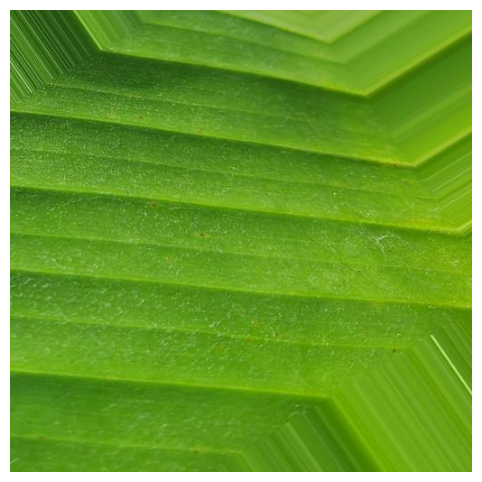

background  [1=plain  2=field  3=hand  4=other]:  1
leaves_in_image  [1=1  2=several]:  1
lesion_visible  [1=yes  2=no  3=unsure]:  2
lesion_size  [1=small  2=medium  3=large  4=na]:  4
lighting  [1=good  2=dark  3=glare]:  1
other_damage  [1=yes  2=no]:  2
usable_for_scope  [1=yes  2=no]:  1


finished


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import clear_output

obs = pd.read_csv("../docs/observations.csv", dtype=str).fillna("")
for i, r in obs.iterrows():
    if r.usable_for_scope != "":
        continue                                  # already rated
    clear_output(wait=True)
    print(f"{i+1}/{len(obs)}   {r.file}")
    plt.figure(figsize=(6, 6)); plt.imshow(Image.open(root / r.file)); plt.axis("off"); plt.show()
    for col, opts in options.items():
        while True:
            menu = "  ".join(f"{k+1}={o}" for k, o in enumerate(opts))
            a = input(f"{col}  [{menu}]: ").strip()
            if a.isdigit() and 1 <= int(a) <= len(opts):
                obs.loc[i, col] = opts[int(a) - 1]
                break
    obs.to_csv("../docs/observations.csv", index=False)
print("finished")

In [9]:
obs = pd.read_csv("../docs/observations.csv", dtype=str)
for col, opts in options.items():
    assert obs[col].notna().all() and obs[col].isin(opts).all(), f"problem in {col}"
print("all 60 rows valid")

all 60 rows valid


In [8]:
print(
    obs[~obs["lesion_visible"].isin(options["lesion_visible"])][
        ["file", "label", "lesion_visible"]
    ].to_string()
)

                                  file                label lesion_visible
40  banana_healthy_leaf/train_0078.png  banana_healthy_leaf             na


In [10]:
print(pd.crosstab(obs.label, obs.usable_for_scope))
print(pd.crosstab(obs.label, obs.background))
print(pd.crosstab(obs.label, obs.leaves_in_image))
print(pd.crosstab(obs.label, obs.lesion_visible))
print(pd.crosstab(obs.label, obs.other_damage))

usable_for_scope     yes
label                   
banana_healthy_leaf   20
black_sigatoka        20
yellow_sigatoka       20
background           field  plain
label                            
banana_healthy_leaf      1     19
black_sigatoka          15      5
yellow_sigatoka         12      8
leaves_in_image       1  several
label                           
banana_healthy_leaf  20        0
black_sigatoka       19        1
yellow_sigatoka      20        0
lesion_visible       no  yes
label                       
banana_healthy_leaf  20    0
black_sigatoka        0   20
yellow_sigatoka       0   20
other_damage         no  yes
label                       
banana_healthy_leaf  20    0
black_sigatoka        4   16
yellow_sigatoka       1   19
